# **Exam Pass Prediction** | 2025

# **I. Data Understanding**

## ***A. Penjabaran Studi Kasus***

yang harus dilakukan :
- bikin fitur baru; Study_Efficiency = previous_score / hours_studied
- bikin pass = 1 jika exam_score >=70, dan else 0 >> bikin biar exam_score jadi klasifikasi
- bedain yg kategorikal dan yg numerikan (buat chi square dan kendall)

## ***B. Import Libraries***

In [352]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tkinter as tk

## ***C. Import Dataset***

In [311]:
dataset = pd.read_csv("StudentPerformanceFactors.csv")
dataset

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


# **II. Data Preparation**

## ***A. Exploratory Data Analysis***

### 1. Inspeksi Daftar Variabel

In [312]:
dataset.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

Penjelasan setiap variabel :
1. Hours_Studied = jumlah jam rata2 belajar para siswa seminggu
2. Attendance = presentase kehadiran siswa di kelas
3. Parental_Involvement = tingkat keterlibatan orang tua dalam proses belajar siswa-siswi
4. Access_to_Resources = ketersediaan dan akses siswa-siswi terhadap sumber belajar
5. Extracurricular_Activities = aktifitas ekstrakulikuler mereka
6. Sleep_Hours = jam tidur siswa-siswi
7. Previous_Score = nilai akademik siswa pada semester sebelumnya
8. Motivation_Level = tingkat motivasi belajar mereka
9. Internet_Access = ketersediaan & akses internet para siswa-siwi
10. Tutoring_Sessions = sesi les
11. Family_Income = pemasukan keluarga/orang tua
12. Teacher_Quality = kualitas pengajar siswa-siswi
13. School_Type = tipe sekolah mereka
14. Peer_Influence = pengaruh teman sebaya terhadap perilaku dan sikap belajar siswa
15. Physical_Activity = jumlah jam rata2 yang dihabiskan siswa untuk aktivitas fisik 
16. Learning_Disabilities = apakah siswa-siswi memiliki disabilitas dalam belajar?
17. Parental_Education_Level = tingkat pendidikan tertinggi yg dicapai oleh orang tua siswa
18. Distance_from_Home = jarak jauh dengan rumah
19. Gender = jenis kelamin siswa-siswi
20. Exam_Score = nilai ujian kelulusan

### 2. Inspeksi Informasi Ringkas

In [313]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [314]:
cat_cols = ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
yesno_cols = ['Extracurricular_Activities', 'Internet_Access', 'Learning_Disabilities']
hml_cols = ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income', 'Teacher_Quality']
num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

### 3. Inspeksi Statistik Deskriptif

In [315]:
dataset.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### 4. Inspeksi Data NaN

In [316]:
dataset.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

### 5. Inspeksi Data Duplicated

In [317]:
dataset.duplicated().sum()

np.int64(0)

### 6. Encoding

In [318]:
dataset = dataset.drop_duplicates()
map_lhm = {'Low' : 0, 'Medium' : 1, 'High' : 2}
map_yesno = {'Yes' : 0, 'No' : 1}
map_type = {'Public' : 0, 'Private' : 1}
map_peer = {'Negative' : 0, 'Neutral' : 1, 'Positive' : 2}
map_edu = {'High School' : 0, 'College' : 1, 'Postgraduate' : 2}
map_distance = {'Near' : 0, 'Moderate' : 1, 'Far' : 2}
map_gender = {'Male' : 0, 'Female' : 1}

dataset[hml_cols] = dataset[hml_cols].replace(map_lhm)
dataset[yesno_cols] = dataset[yesno_cols].replace(map_yesno)
dataset['School_Type'] = dataset['School_Type'].map(map_type)
dataset['Peer_Influence'] = dataset['Peer_Influence'].map(map_peer)
dataset['Parental_Education_Level'] = dataset['Parental_Education_Level'].map(map_edu)
dataset['Distance_from_Home'] = dataset['Distance_from_Home'].map(map_distance)
dataset['Gender'] = dataset['Gender'].map(map_gender)

C:\Users\USER\AppData\Local\Temp\ipykernel_920\1434245208.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset[hml_cols] = dataset[hml_cols].replace(map_lhm)
C:\Users\USER\AppData\Local\Temp\ipykernel_920\1434245208.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset[yesno_cols] = dataset[yesno_cols].replace(map_yesno)


### 7. Feature Engineering

#### a. Exam_Score jadi 0 dan 1 > Pass and Not Pass

In [319]:
dataset['Exam_Pass'] = np.where(dataset['Exam_Score'] >= 70, 1, 0)  # 1 = Pass, 0 = Not Pass

#### b. Study_Efficiency

In [320]:
dataset['Study_Efficiency'] = dataset['Previous_Scores'] / dataset['Hours_Studied']
dataset['Study_Efficiency']

0       3.173913
1       3.105263
2       3.791667
3       3.379310
4       3.421053
          ...   
6602    3.040000
6603    3.521739
6604    3.250000
6605    9.100000
6606    6.266667
Name: Study_Efficiency, Length: 6607, dtype: float64

In [321]:
all_feature = ['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Study_Efficiency']

### 8. Univariate Analysis

#### a. Inspeksi Distribusi Kelas Target

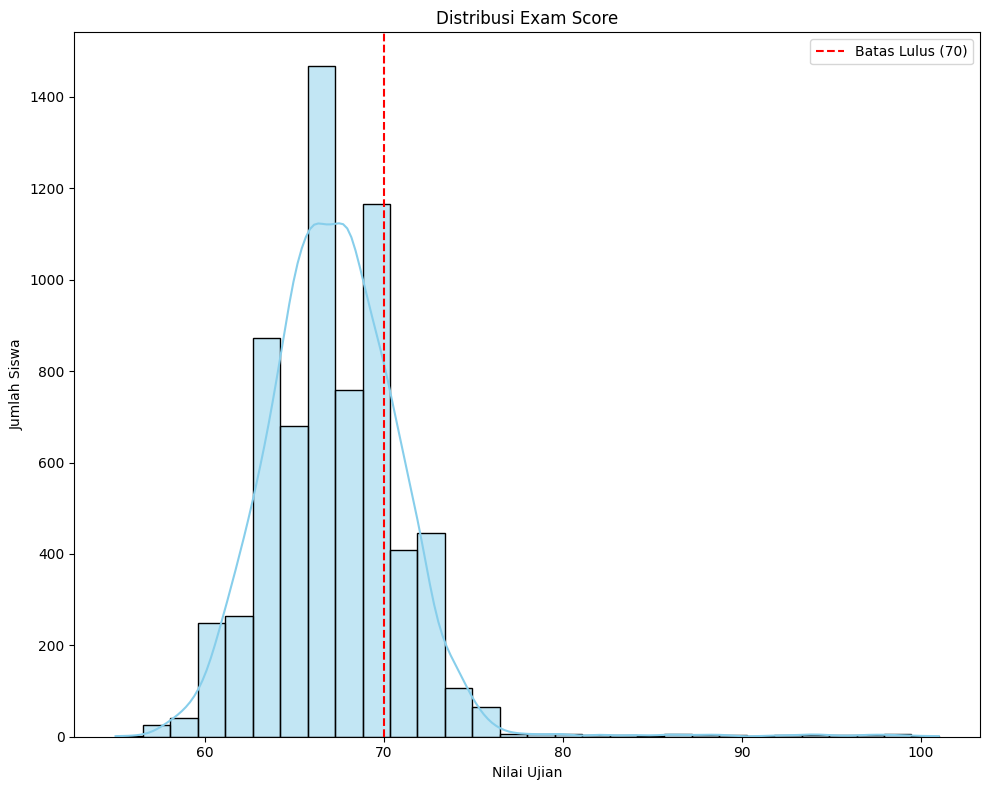

In [322]:
plt.figure(figsize=(10,8))
sns.histplot(dataset['Exam_Score'], bins=30, kde=True, color='skyblue', edgecolor='black')
plt.title("Distribusi Exam Score")
plt.xlabel("Nilai Ujian")
plt.ylabel("Jumlah Siswa")
plt.axvline(x=70, color="red", linestyle="--", label="Batas Lulus (70)")
plt.legend()
plt.tight_layout()
plt.show()

In [323]:
target_count = dataset['Exam_Pass'].value_counts()
target_count

Exam_Pass
0    4982
1    1625
Name: count, dtype: int64

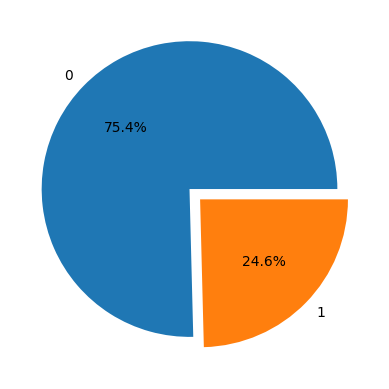

<Figure size 1000x1000 with 0 Axes>

In [324]:
explode = [0.05] * len(target_count)
plt.pie(target_count, labels=target_count.index, explode=explode, autopct="%1.1f%%")
plt.figure(figsize=(10,10))
plt.show()

#### b. Inspeksi Distribusi Kelas Fitur

In [325]:
def check_value(cols, top_n=1):
    for col in cols:
        print(f"Kolom: {col}")
        print(dataset[col].value_counts().head(top_n))
        print("\n")
check_value(all_feature, top_n=1)

Kolom: Hours_Studied
Hours_Studied
20    465
Name: count, dtype: int64


Kolom: Attendance
Attendance
67    190
Name: count, dtype: int64


Kolom: Parental_Involvement
Parental_Involvement
1    3362
Name: count, dtype: int64


Kolom: Access_to_Resources
Access_to_Resources
1    3319
Name: count, dtype: int64


Kolom: Extracurricular_Activities
Extracurricular_Activities
0    3938
Name: count, dtype: int64


Kolom: Sleep_Hours
Sleep_Hours
7    1741
Name: count, dtype: int64


Kolom: Previous_Scores
Previous_Scores
66    165
Name: count, dtype: int64


Kolom: Motivation_Level
Motivation_Level
1    3351
Name: count, dtype: int64


Kolom: Internet_Access
Internet_Access
0    6108
Name: count, dtype: int64


Kolom: Tutoring_Sessions
Tutoring_Sessions
1    2179
Name: count, dtype: int64


Kolom: Family_Income
Family_Income
0    2672
Name: count, dtype: int64


Kolom: Teacher_Quality
Teacher_Quality
1.0    3925
Name: count, dtype: int64


Kolom: School_Type
School_Type
0    4598
Name: count, 

### 9. Bivariate Analysis

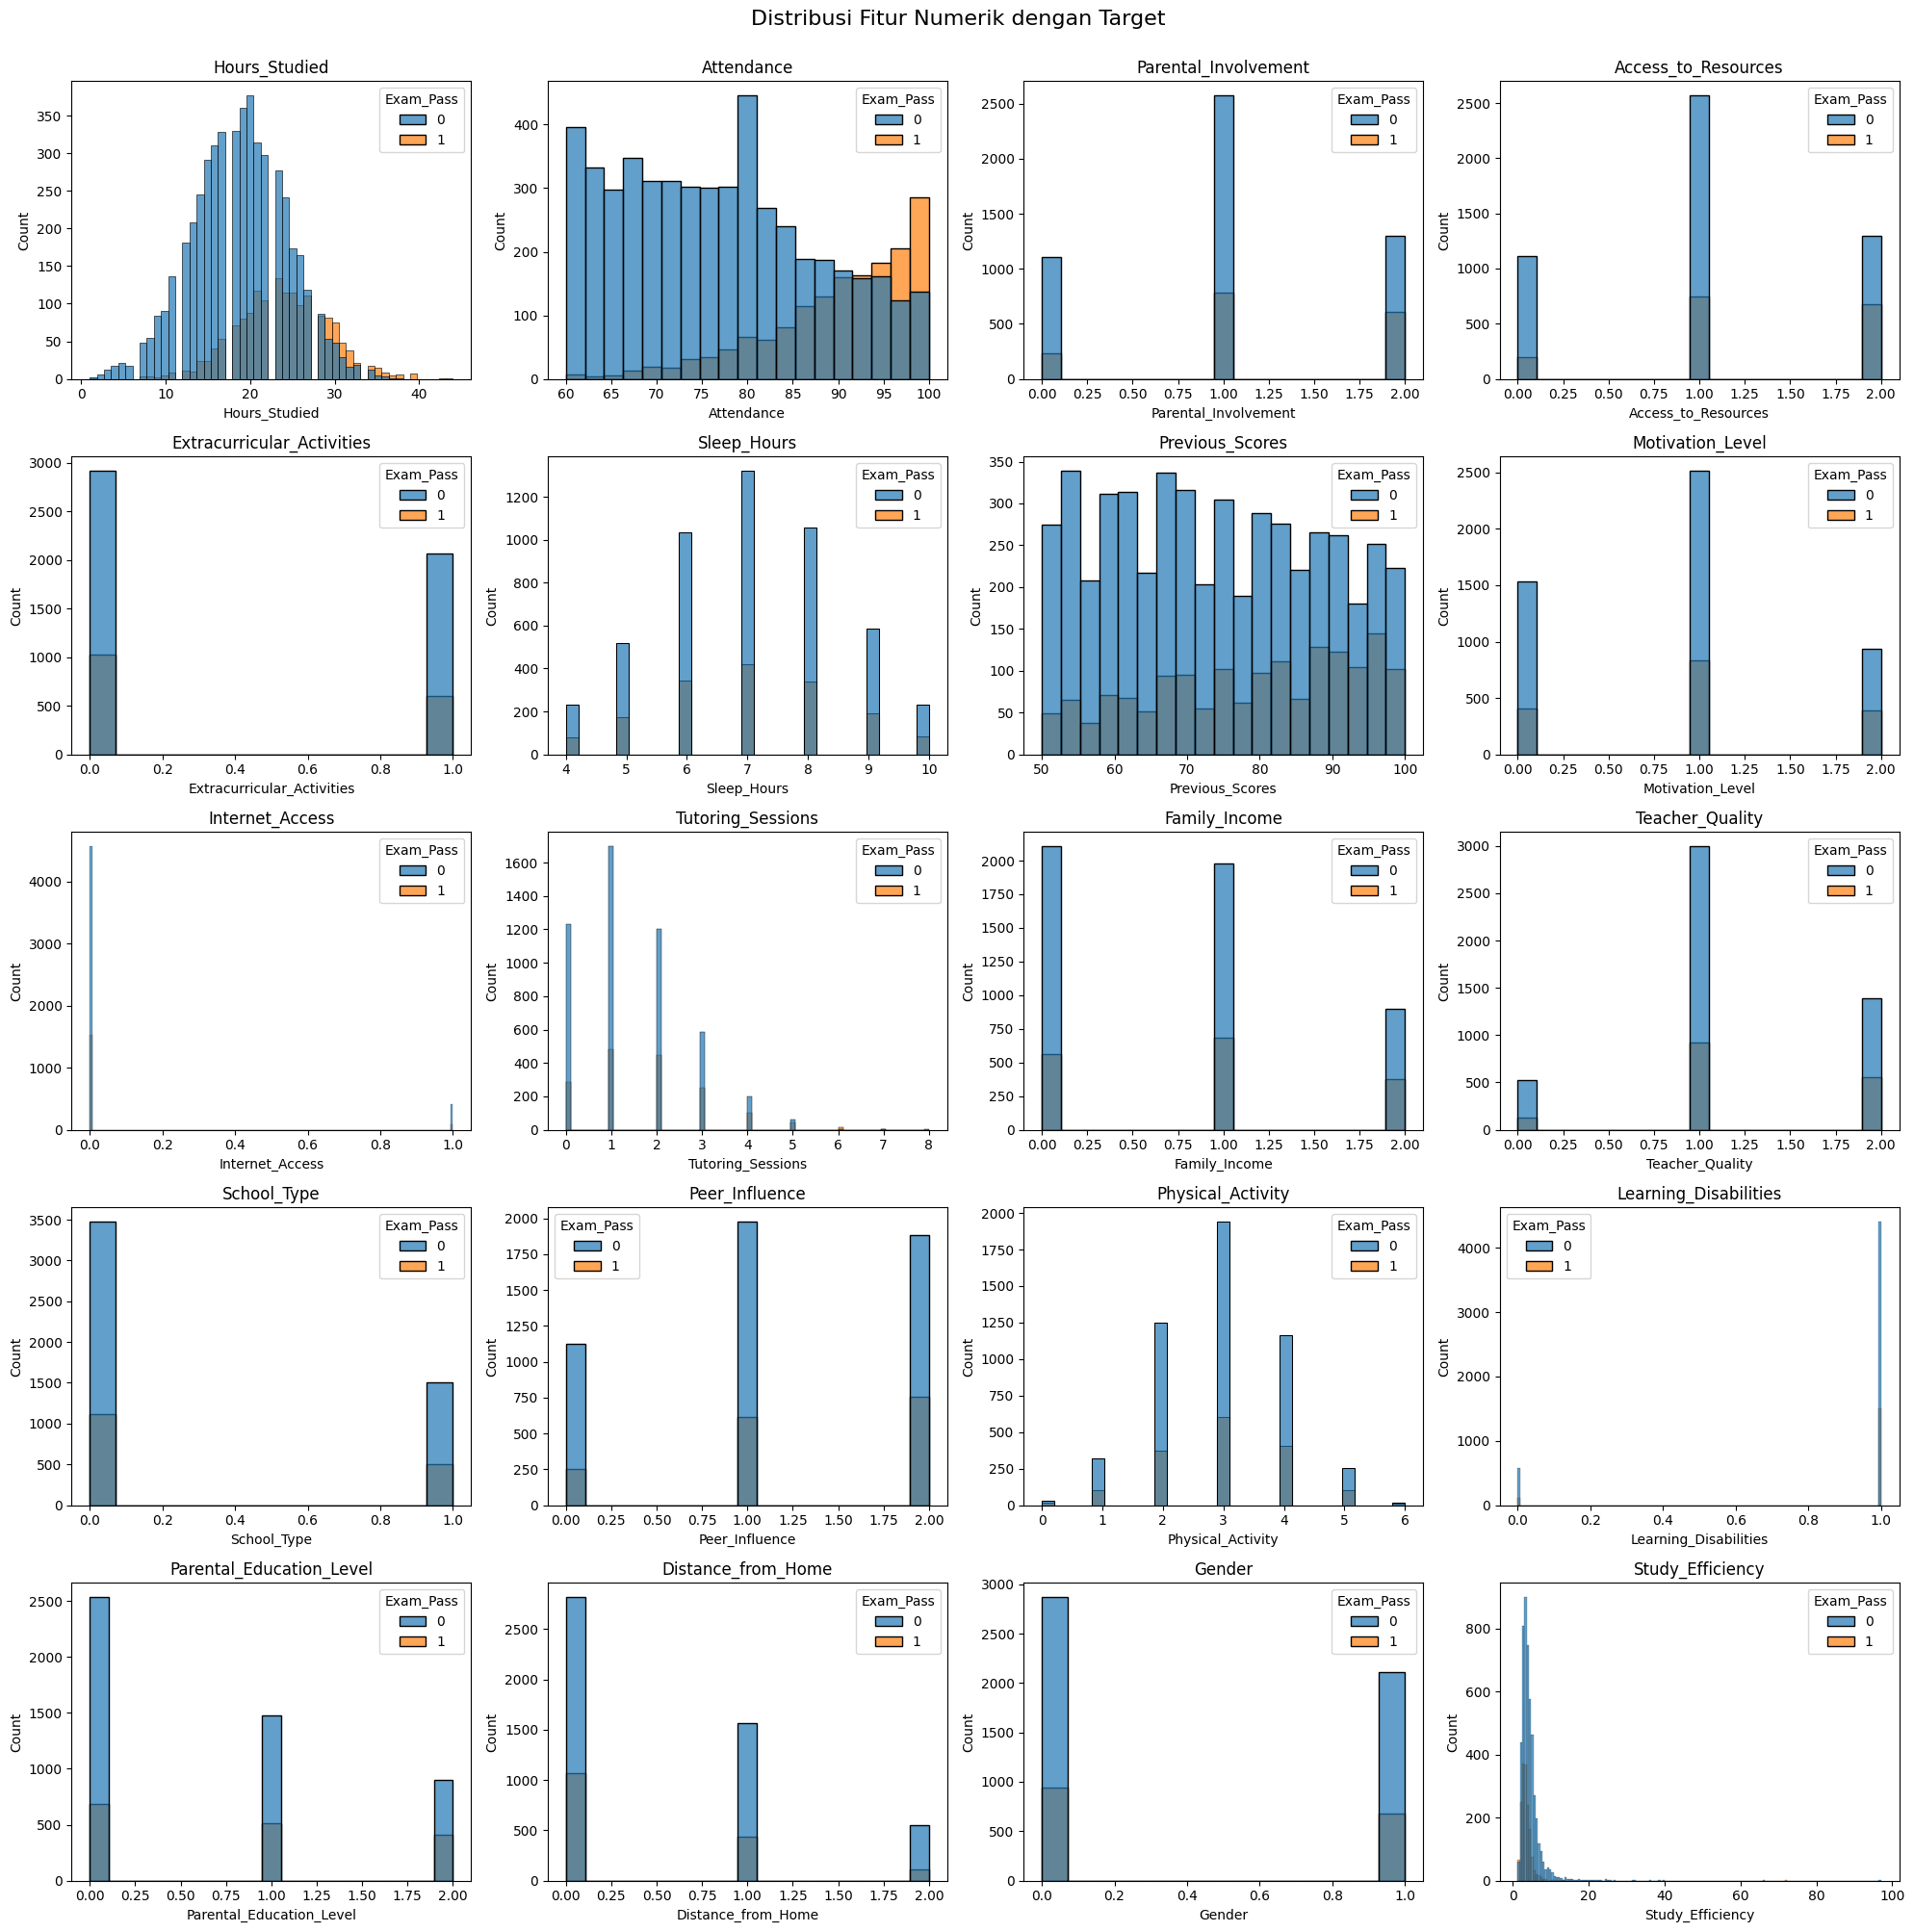

In [326]:
n_features = len(all_feature)
n_cols_plot = 4
n_rows_plot = int(np.ceil(n_features / n_cols_plot))

plt.figure(figsize=(20, n_rows_plot * 4))

for i, col in enumerate(all_feature):
    plt.subplot(n_rows_plot, n_cols_plot, i+1)
    sns.histplot(data=dataset, x=col, hue='Exam_Pass', kde=False, alpha=0.7)
    plt.title(col)

plt.suptitle("Distribusi Fitur Numerik dengan Target", y=1.001, fontsize=16)
plt.tight_layout()
plt.show()

### 10. Multivariate Analysis

In [327]:
# sns.pairplot(data=dataset, hue="Exam_Pass")

### 11. Inspeksi Korelasi

#### a. Mutual Information

In [328]:
def probability_distribution(x):
    unique, counts = np.unique(x, return_counts=True)
    return counts / counts.sum()

def calculate_entropy(x):
    probs = probability_distribution(x)
    return -np.sum(probs * np.log2(probs + 1e-10))

def mutual_information(x, y):
    xy_pairs = list(zip(x, y))
    unique_xy, counts_xy = np.unique(xy_pairs, return_counts=True)
    probs_xy = counts_xy / counts_xy.sum()
    entropy_xy = -np.sum(probs_xy * np.log2(probs_xy + 1e-10))

    entropy_x = calculate_entropy(x)
    entropy_y = calculate_entropy(y)
    return entropy_x + entropy_y - entropy_xy

fitur = dataset[all_feature]
target = dataset["Exam_Pass"]

mi_scores = {col: mutual_information(fitur[col].values, target.values) for col in fitur.columns}
mi_df = pd.DataFrame(list(mi_scores.items()), columns=["Feature", "Mutual Information"])
mi_df = mi_df.sort_values(by="Mutual Information", ascending=False)

C:\Users\USER\AppData\Local\Temp\ipykernel_920\4036349343.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="magma")
C:\Users\USER\AppData\Local\Temp\ipykernel_920\4036349343.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


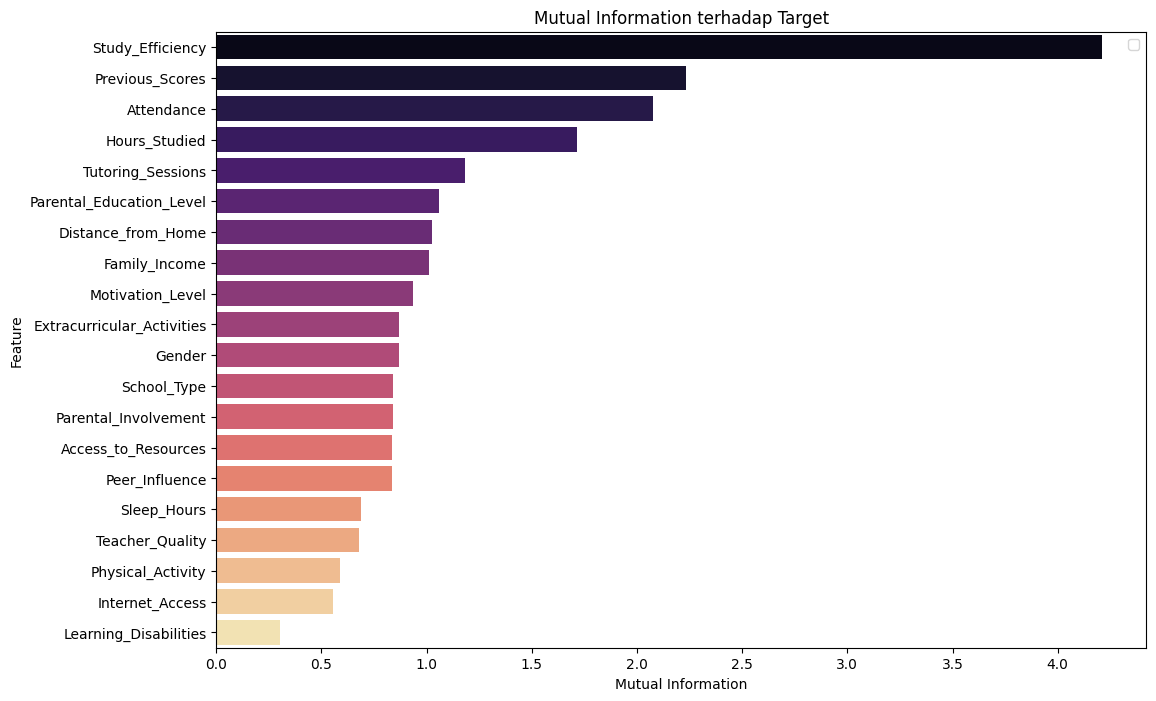

In [329]:
plt.figure(figsize=(12, 8))
sns.barplot(data=mi_df, x="Mutual Information", y="Feature", palette="magma")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.title("Mutual Information terhadap Target")
plt.legend()
plt.show()

#### b. Kendall Method

In [330]:
def kendall_method(x, y):
    concordant = 0
    discordant = 0
    n = len(x)

    for i in range(n - 1):
        for j in range(i+1, n):
            x_diff = x[i] - x[j]
            y_diff = y[i] - y[j]

            if x_diff * y_diff > 0:
                concordant += 1
            if x_diff * y_diff < 0:
                discordant += 1

    if (concordant - discordant) == 0:
        return 0
    
    return (concordant - discordant) / (concordant + discordant)

In [331]:
# kendall_all = pd.DataFrame(index=all_feature, columns=all_feature)
# for col1 in all_feature:
#     for col2 in all_feature:
#         kendall_all.loc[col1, col2] = kendall_method(dataset[col1].values, dataset[col2].values)
    
# kendall_all = kendall_all.astype(float)
# # plt.figure(figsize=(9,9))
# # sns.heatmap(kendall_all, fmt=".2f", annot=True, cmap="coolwarm")
# # plt.show()

In [332]:
# kendall_all

#### c. Chi Square Method

In [333]:
def chi_square(data, col1, col2):
    observed = pd.crosstab(data[col1], data[col2])
    totals = observed.values.sum()
    row_totals = observed.sum(axis=1).values.reshape(-1, 1)
    col_totals = observed.sum(axis=0).values.reshape(1, -1)

    expected = row_totals @ col_totals / totals
    chi_square = ((observed.values - expected) ** 2 / expected).sum()

    return chi_square

chi_scores = []

for col in cat_cols:
    chi = chi_square(dataset, col, 'Exam_Pass')
    chi_scores.append((col, chi))

chi_df = pd.DataFrame(chi_scores, columns=['Feature', 'Chi Scores'])
chi_df = chi_df.sort_values(by="Chi Scores", ascending=False)
chi_df

,Feature,Chi Scores
1,Access_to_Resources,166.195590
0,Parental_Involvement,97.921852
8,Peer_Influence,52.609700
10,Parental_Education_Level,50.208830
11,Distance_from_Home,45.778602
5,Family_Income,34.880901
3,Motivation_Level,31.203487
6,Teacher_Quality,28.909962
9,Learning_Disabilities,22.495128
4,Internet_Access,14.098011


C:\Users\USER\AppData\Local\Temp\ipykernel_920\3627739819.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chi_df, x="Feature", y="Chi Scores", palette='magma')


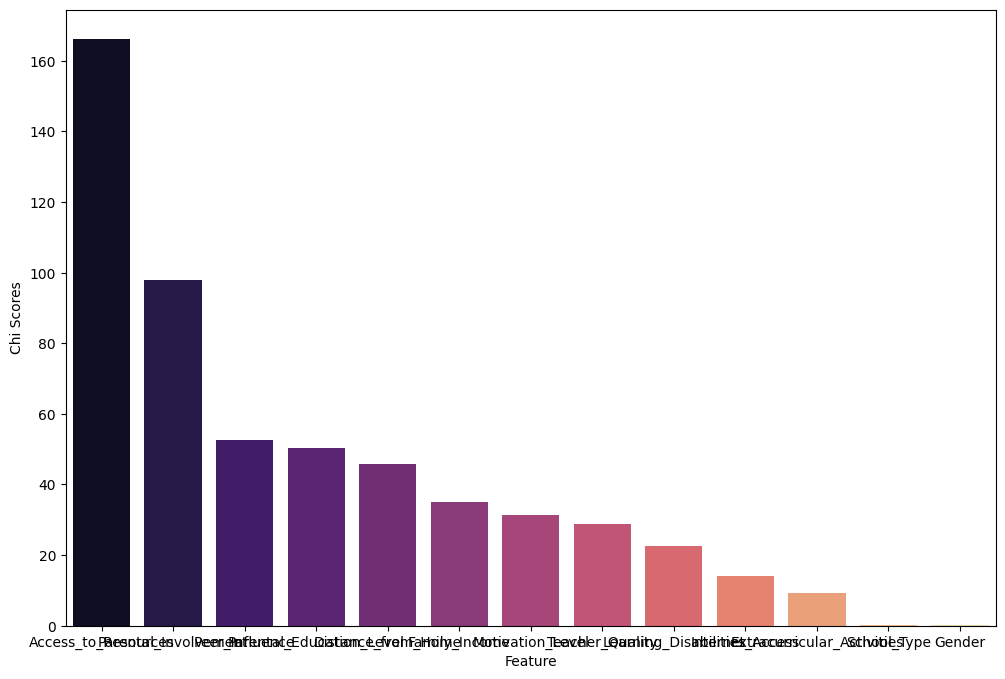

In [334]:
plt.figure(figsize=(12,8))
sns.barplot(data=chi_df, x="Feature", y="Chi Scores", palette='magma')
plt.show()

### 12. Inspeksi Outlier

<Axes: xlabel='Exam_Pass', ylabel='Study_Efficiency'>

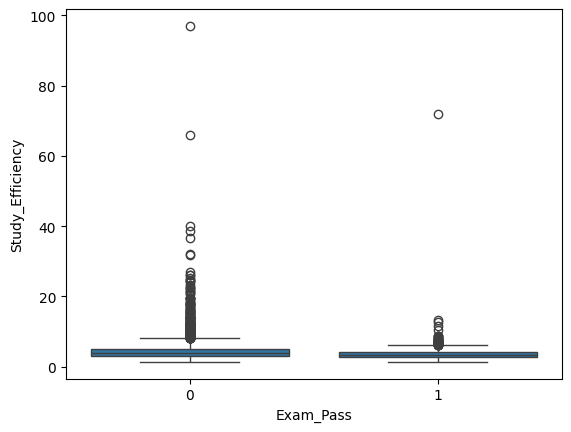

In [335]:
sns.boxplot(data=dataset, x="Exam_Pass", y="Study_Efficiency")

## ***B. Feature Selection***

In [336]:
feature_cols = ['Study_Efficiency', 'Previous_Scores', 'Attendance', 'Hours_Studied', 'Tutoring_Sessions']

## ***C. Data Preprocessing***

#### 1. Data Imbalance

In [337]:
dataset['Exam_Pass'].value_counts(normalize=True)*100

Exam_Pass
0    75.404874
1    24.595126
Name: proportion, dtype: float64

#### 2. Data Scaling

In [338]:
means = dataset[num_cols].mean().values
stds = dataset[num_cols].std().values
stds = np.where(stds == 0, 1, stds)

dataset_scaled = dataset.copy()
dataset_scaled[num_cols] = (dataset[num_cols].values - means) / stds

dataset = dataset_scaled

dataset[num_cols].describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity
count,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03,6.607000e+03
mean,-1.247510e-16,-3.011230e-16,-1.742212e-16,2.145501e-16,8.495970e-17,-6.882811e-17
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-3.167520e+00,-1.730027e+00,-2.063223e+00,-1.741035e+00,-1.213843e+00,-2.877735e+00
25%,-6.635951e-01,-8.640372e-01,-7.009372e-01,-8.382439e-01,-4.012113e-01,-9.383058e-01
50%,4.118256e-03,1.952967e-03,-1.979408e-02,-4.898077e-03,-4.012113e-01,3.140895e-02
75%,6.718316e-01,8.679432e-01,6.613490e-01,8.978932e-01,4.114199e-01,1.001124e+00
max,4.010399e+00,1.733933e+00,2.023635e+00,1.731239e+00,5.287208e+00,2.940553e+00


Tidak menghandle data NaN sebab data NaN ada di variabel Teacher_Quality, Parental_Education_Level, dan Distance_from_Home. Semua fitur itu tidak termasuk dalam feature selection kami, jadi tidak kami handle

## ***D. Splitting Dataset***

In [339]:
def stratified_split(dataset, target_column, training_size=0.8, random_state=42):
    np.random.seed(random_state)
    train_list, test_list = [], []

    for class_value in dataset[target_column].unique():
        class_data = dataset[dataset[target_column] == class_value]
        class_data = class_data.sample(frac=1, random_state=random_state)

        split_idx = int(len(class_data) * training_size)
        train_list.append(class_data.iloc[:split_idx])
        test_list.append(class_data.iloc[split_idx:])

    train_set = pd.concat(train_list).reset_index(drop=True)
    test_set = pd.concat(test_list).reset_index(drop=True)
    return train_set, test_set

dataset_training, dataset_testing = stratified_split(dataset, "Exam_Pass")

## ***E. Data Sampling***

In [340]:
df_majority = dataset_training[dataset_training['Exam_Pass'] == 0]
df_minority = dataset_training[dataset_training['Exam_Pass'] == 1]

n_minority = len(df_minority)
df_majority_downsampled = df_majority.sample(n=n_minority, random_state=42)

dataset_balanced = pd.concat([df_majority_downsampled, df_minority]).sample(frac=1, random_state=42).reset_index(drop=True)

dataset_training = dataset_balanced
dataset_training['Exam_Pass'].value_counts()

Exam_Pass
1    1300
0    1300
Name: count, dtype: int64

## ***F. Feature Target Declaration***

In [341]:
X_train = dataset_training[feature_cols].to_numpy()
X_test = dataset_testing[feature_cols].to_numpy()

y_train = dataset_training['Exam_Pass'].to_numpy()
y_test = dataset_testing['Exam_Pass'].to_numpy()

# **III. Modeling**

## ***A. Model Application***

In [342]:
class SVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        y_ = np.where(y <= 0, -1, 1)
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]
    
    def predict(self, X):
        approx = np.dot(X, self.w) - self.b
        return np.where(approx >= 0, 1, 0)
    
svm_model = SVM(learning_rate=0.001, lambda_param=0.01, n_iters=2000)
svm_model.fit(X_train, y_train)

y_pred_train = svm_model.predict(X_train)
y_pred_test = svm_model.predict(X_test)

## ***B. Visualisasi Model***

### 1. Distribusi Hasil Prediksi

#### a. Training Model

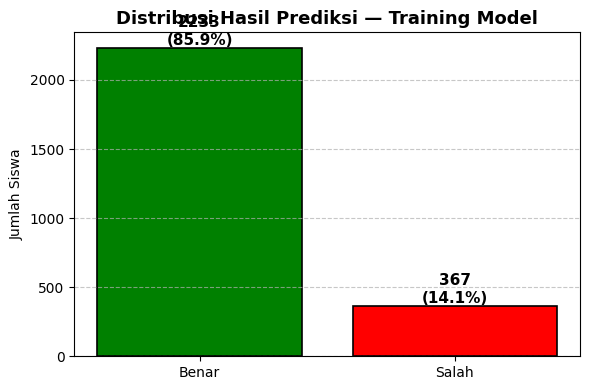

In [343]:
train_correct = np.sum(y_train == y_pred_train)
train_incorrect = len(y_train) - train_correct

plt.figure(figsize=(6, 4))
bars_train = plt.bar(['Benar', 'Salah'], [train_correct, train_incorrect], 
                     color=['green', 'red'], edgecolor='black', linewidth=1.2)

for bar in bars_train:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}\n({height/len(y_train):.1%})', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title("Distribusi Hasil Prediksi — Training Model", fontsize=13, fontweight='bold')
plt.ylabel("Jumlah Siswa")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### b. Testing Model

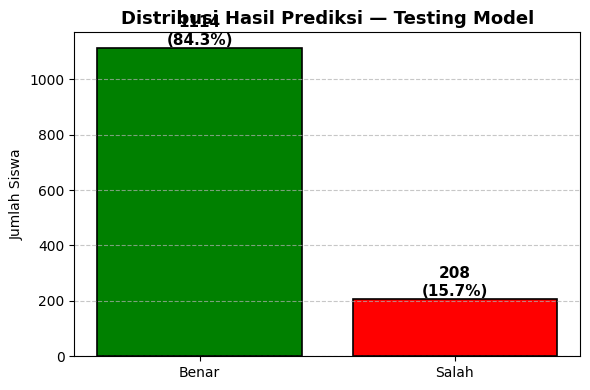

In [344]:
test_correct = np.sum(y_test == y_pred_test)
test_incorrect = len(y_test) - test_correct

plt.figure(figsize=(6, 4))
bars_test = plt.bar(['Benar', 'Salah'], [test_correct, test_incorrect], 
                    color=['green', 'red'], edgecolor='black', linewidth=1.2)

for bar in bars_test:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}\n({height/len(y_test):.1%})', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title("Distribusi Hasil Prediksi — Testing Model", fontsize=13, fontweight='bold')
plt.ylabel("Jumlah Siswa")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2. Confusion Matrix

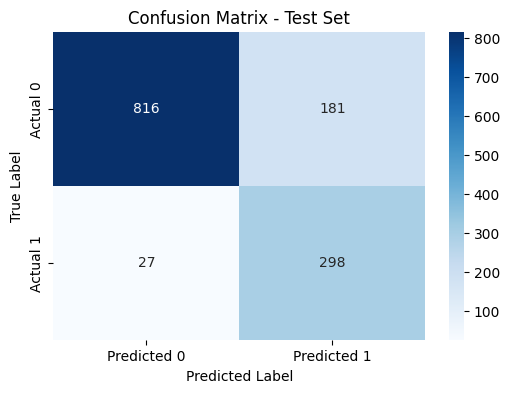

In [345]:
def plot_confusion_matrix_manual(y_true, y_pred, title="Confusion Matrix"):
    cm = np.zeros((2,2))
    for i in range(len(y_true)):
        cm[int(y_true[i]), int(y_pred[i])] += 1

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', 
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

plot_confusion_matrix_manual(y_test, y_pred_test, title="Confusion Matrix - Test Set")

## ***C. Evaluasi Model***

### 1. Confusion Matrix

In [346]:
def accuracy_score(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

def precision_recall_f1(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1

#### a. Training Model

In [347]:
acc_train = accuracy_score(y_train, y_pred_train)
prec_train, rec_train, f1_train = precision_recall_f1(y_train, y_pred_train)

print(f"Training Accuracy   : {acc_train:.4f}")
print(f"Training Precision  : {prec_train:.4f}")
print(f"Training Recall     : {rec_train:.4f}")
print(f"Training F1-Score   : {f1_train:.4f}")

Training Accuracy   : 0.8588
Training Precision  : 0.8344
Training Recall     : 0.8954
Training F1-Score   : 0.8638


#### b. Testing Model

In [348]:
acc_test = accuracy_score(y_test, y_pred_test)
prec_test, rec_test, f1_test = precision_recall_f1(y_test, y_pred_test)

print(f"Testing Accuracy    : {acc_test:.4f}")
print(f"Testing Precision   : {prec_test:.4f}")
print(f"Testing Recall      : {rec_test:.4f}")
print(f"Testing F1-Score    : {f1_test:.4f}")

Testing Accuracy    : 0.8427
Testing Precision   : 0.6221
Testing Recall      : 0.9169
Testing F1-Score    : 0.7413


### 2. Bias and Variance Model

In [349]:
bias = 100 - acc_test
variance = acc_train - acc_test

data = {
    'Metric': ['Bias', 'Variance'],
    'Value': [bias, variance]
}
data_eval = pd.DataFrame(data)

C:\Users\USER\AppData\Local\Temp\ipykernel_920\342690677.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data_eval, x="Metric", y="Value", palette="viridis")


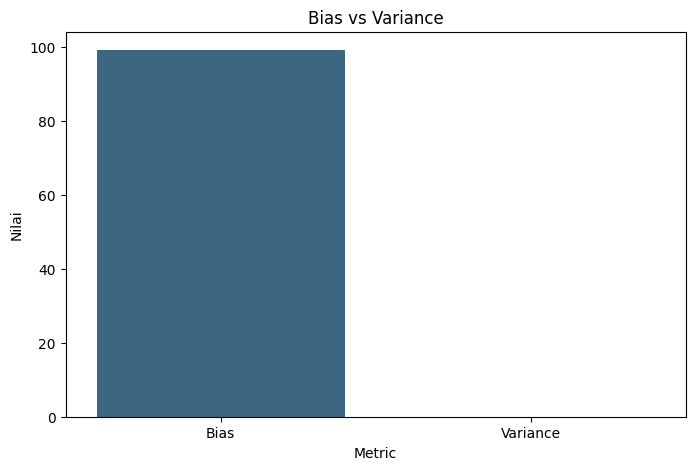

In [350]:
plt.figure(figsize=(8,5))
sns.barplot(data=data_eval, x="Metric", y="Value", palette="viridis")
plt.title("Bias vs Variance")
plt.ylabel("Nilai")
plt.show()

### 3. K-Fold Cross Validation

In [351]:
def k_fold_split(X, y, k=5, random_state=42):
    np.random.seed(random_state)
    n_samples = len(X)
    indices = np.random.permutation(n_samples)
    fold_sizes = np.full(k, n_samples // k)
    fold_sizes[:n_samples % k] += 1
    current = 0
    folds = []

    for fold_size in fold_sizes:
        start, stop = current, current + fold_size
        fold_indices = indices[start:stop]
        folds.append(fold_indices)
        current = stop
    return folds

def cross_validate(X, y, k=5, random_state=42):
    folds = k_fold_split(X, y, k=k, random_state=random_state)
    scores = []

    for i in range(k):
        val_indices = folds[i]
        train_indices = np.concatenate([folds[j] for j in range(k) if j != i])
        X_train_fold = X[train_indices]
        y_train_fold = y[train_indices]
        X_val_fold = X[val_indices]
        y_val_fold = y[val_indices]

        model = SVM(learning_rate=0.001, lambda_param=0.01, n_iters=2000)
        model.fit(X_train_fold, y_train_fold)

        y_pred_val = model.predict(X_val_fold)
        acc = np.sum(y_pred_val == y_val_fold) / len(y_val_fold)
        scores.append(acc)

        print(f"Fold {i+1}: Akurasi = {acc:.4f}")

    mean_acc = np.mean(scores)
    std_acc = np.std(scores)
    print(f"Rata-rata akurasi cross validation ({k}-Fold): {mean_acc:.4f} ± {std_acc:.4f}")

    return scores, mean_acc, std_acc

cv_scores, cv_mean, cv_std = cross_validate(X_train, y_train, k=5, random_state=42)

Fold 1: Akurasi = 0.8731
Fold 2: Akurasi = 0.8500
Fold 3: Akurasi = 0.8519
Fold 4: Akurasi = 0.8692
Fold 5: Akurasi = 0.8365
Rata-rata akurasi cross validation (5-Fold): 0.8562 ± 0.0134


# **IV. GUI**

In [353]:
def predict_gui():
    try:
        # Ambil nilai dari input
        study_eff = float(entry_study_eff.get())
        prev_score = float(entry_prev_score.get())
        attendance = float(entry_attendance.get())
        hours_studied = float(entry_hours_studied.get())
        tutoring = float(entry_tutoring.get())
        
        # Gabung jadi array fitur
        sample = np.array([[study_eff, prev_score, attendance, hours_studied, tutoring]])
        
        # Prediksi pake model SVM manual
        prediction = svm_model.predict(sample)[0]
        decision_score = np.dot(sample, svm_model.w) - svm_model.b
        
        # Tampilkan hasil
        if prediction == 1:
            result = "✅ LULUS"
            color = "green"
        else:
            result = "❌ TIDAK LULUS"
            color = "red"
        
        label_result.config(text=f"Hasil: {result}\n(Skor: {decision_score[0]:.2f})", fg=color)
        label_error.config(text="")  # Bersihkan error sebelumnya

    except ValueError:
        label_error.config(text="⚠️ Masukkan semua nilai dengan benar (angka!)", fg="red")
    except Exception:
        label_error.config(text="⚠️ Terjadi kesalahan tak terduga.", fg="red")

# Buat window utama
root = tk.Tk()
root.title("🎓 Prediksi Kelulusan Ujian")
root.geometry("500x650")
root.configure(bg='#f0f8ff')

# Judul
title_label = tk.Label(root, text="🎓 PREDIKSI KELULUSAN", font=("Arial", 18, "bold"), bg='#f0f8ff', fg='#1e3d59')
title_label.pack(pady=20)

# Frame input
frame_input = tk.Frame(root, bg='#ffffff', padx=20, pady=20, relief="groove", borderwidth=2)
frame_input.pack(pady=10, padx=20, fill="both")

# Label & Entry untuk setiap fitur
fields = [
    ("Study Efficiency", "entry_study_eff"),
    ("Previous Score", "entry_prev_score"),
    ("Attendance (%)", "entry_attendance"),
    ("Hours Studied", "entry_hours_studied"),
    ("Tutoring Sessions", "entry_tutoring")
]

entries = {}
for i, (label_text, var_name) in enumerate(fields):
    tk.Label(frame_input, text=label_text, font=("Arial", 11), bg='white', anchor='w').grid(row=i, column=0, sticky='w', pady=5)
    entry = tk.Entry(frame_input, width=20, font=("Arial", 11))
    entry.grid(row=i, column=1, padx=10, pady=5)
    entries[var_name] = entry

# Assign ke variabel global biar bisa dipakai di fungsi
globals().update(entries)

# Tombol Prediksi
btn_predict = tk.Button(root, text="🔮 PREDIKSI SEKARANG", command=predict_gui,
                        font=("Arial", 12, "bold"), bg='#007bff', fg='white',
                        activebackground='#0056b3', padx=20, pady=10)
btn_predict.pack(pady=20)

# Label Error (pengganti messagebox)
label_error = tk.Label(root, text="", font=("Arial", 10), bg='#f0f8ff')
label_error.pack(pady=5)

# Label Hasil
label_result = tk.Label(root, text="Hasil akan muncul di sini", font=("Arial", 14, "bold"), bg='#f0f8ff')
label_result.pack(pady=20)

# Footer
footer = tk.Label(root, text="© 2025 Exam Pass Prediction System | Manual SVM", font=("Arial", 9), bg='#f0f8ff', fg='gray')
footer.pack(side="bottom", pady=10)

# Jalankan GUI
root.mainloop()